<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/%D0%94%D0%97_6_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1_random_Markov_processes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание:

Скачайте текст произведения «Война и мир»: ссылка на GitHub.

Очистите его, оставив только русские буквы и символы пробела.

Постройте матрицу переходных вероятностей.

Посчитайте вероятность встретить строку из четырёх символов, которая начинается на букву «П» и заканчивается на букву «Р».

Используя матрицу переходных вероятностей, сгенерируйте слово, начинающееся с буквы «Б» длиной восемь символов.

Выберите ряд из предыдущих домашних заданий по временным рядам и оцените его через HMM.

Попробуйте построить через среднее каждой компоненты наивный прогноз ряда.

In [ ]:
!pip install pyts matplotlib numpy pandas --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline
sns.set()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Путь к датасету
DATA_PATH = '/content/drive/MyDrive/0. DataScients (Netology)/Временные ряды/2/'

In [ ]:
with open(DATA_PATH + 'tom_1.txt', 'r') as f:
    text1 = f.read().lower()
text1 = re.sub('[^а-я]','', text1)

In [ ]:
with open(DATA_PATH + 'tom_2.txt', 'r') as f:
    text2 = f.read().lower()
text2 = re.sub('[^а-я]','', text2)

In [ ]:
with open(DATA_PATH + 'tom_3.txt', 'r') as f:
    text3 = f.read().lower()
text3 = re.sub('[^а-я]','', text3)

In [ ]:
with open(DATA_PATH + 'tom_4.txt', 'r') as f:
    text4 = f.read().lower()
text4 = re.sub('[^а-я]','', text4)

In [ ]:
# Объединяем тексты
full_text = text1 + text2 + text3 + text4

In [ ]:
# Очищаем текст, оставляя только русские буквы и пробелы
cleaned_text = re.sub(r'[^а-яё\s]', '', full_text)
# Заменяем множественные пробелы на один
cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

In [ ]:
# Выводим длину очищенного текста для проверки
print(f"Длина очищенного текста: {len(cleaned_text)} символов")
print(f"Пример очищенного текста: {cleaned_text[:200]}...")

Длина очищенного текста: 2299965 символов
Пример очищенного текста: левтолстойвойнаимиртомтомчастьперваячастьораячастьтретьятомлевниколаевичтолстойвойнаимиртомчастьперваяепоместьямойверныйрабнучтокнязьгенуаилуккасталинебольшекакпоместьямифамилиибонапартенетяваспредупр...


In [ ]:
# Определяем уникальные символы
unique_chars = sorted(list(set(cleaned_text)))
char_to_idx = {char: idx for idx, char in enumerate(unique_chars)}
idx_to_char = {idx: char for idx, char in enumerate(unique_chars)}

n_chars = len(unique_chars)
print(f"Количество уникальных символов: {n_chars}")

Количество уникальных символов: 32


In [ ]:
# Инициализация матрицы переходных вероятностей
transition_matrix = np.zeros((n_chars, n_chars))

In [ ]:
# Подсчет переходов
for i in range(len(cleaned_text) - 1):
    current_char = cleaned_text[i]
    next_char = cleaned_text[i+1]
    current_idx = char_to_idx[current_char]
    next_idx = char_to_idx[next_char]
    transition_matrix[current_idx][next_idx] += 1

In [ ]:
# Нормализация для получения вероятностей
row_sums = transition_matrix.sum(axis=1, keepdims=True)
# Избегаем деления на ноль
row_sums[row_sums == 0] = 1
transition_matrix = transition_matrix / row_sums

print("Матрица переходных вероятностей построена.")

Матрица переходных вероятностей построена.


In [ ]:
# Печать примера матрицы
print("\nПример матрицы переходных вероятностей (первые 10x10):")
print(pd.DataFrame(transition_matrix[:10, :10],
                   index=unique_chars[:10],
                   columns=unique_chars[:10]))


Пример матрицы переходных вероятностей (первые 10x10):
          а         б         в         г         д         е         ж  \
а  0.003376  0.018440  0.067412  0.018196  0.037984  0.020962  0.018541   
б  0.065845  0.000900  0.006102  0.000775  0.001701  0.142343  0.000550   
в  0.141206  0.005609  0.010091  0.008625  0.016593  0.115528  0.001297   
г  0.056614  0.001987  0.006072  0.000861  0.066241  0.031531  0.000442   
д  0.165688  0.002681  0.040610  0.002142  0.002383  0.171745  0.000780   
е  0.002370  0.028272  0.044181  0.055789  0.048848  0.027982  0.017762   
ж  0.149182  0.006814  0.002203  0.001999  0.082589  0.411597  0.002203   
з  0.358179  0.014157  0.060382  0.029455  0.050512  0.017379  0.011569   
и  0.004689  0.021709  0.076959  0.018173  0.042316  0.054686  0.009615   
й  0.015283  0.032273  0.066757  0.029325  0.067261  0.011404  0.014624   

          з         и         й  
а  0.061972  0.019512  0.009135  
б  0.000250  0.050415  0.000000  
в  0.015362  0.0

In [ ]:
# Находим индексы для 'п' и 'р'
char_p_idx = char_to_idx.get('п')
char_r_idx = char_to_idx.get('р')

if char_p_idx is None or char_r_idx is None:
    print("Символы 'п' или 'р' не найдены в тексте.")
    prob_4char_string = 0
else:
    # Для простоты: P(начинается на 'п' и заканчивается на 'р') = P('п') * P(переходы внутри) * P('р')
    # Но так как нам не заданы внутренние символы, можно рассмотреть все возможные пути длины 4:
    # 'п' -> ? -> ? -> 'р'
    # Вероятность = сумма по всем возможным второму и третьему символам
    prob_4char_string = 0
    for idx2 in range(n_chars):
        for idx3 in range(n_chars):
            # P(п -> idx2) * P(idx2 -> idx3) * P(idx3 -> р)
            prob_4char_string += (
                transition_matrix[char_p_idx][idx2] *
                transition_matrix[idx2][idx3] *
                transition_matrix[idx3][char_r_idx]
            )

    print(f"Вероятность встретить строку длины 4, начинающуюся на 'п' и заканчивающуюся на 'р': {prob_4char_string:.6f}")


Вероятность встретить строку длины 4, начинающуюся на 'п' и заканчивающуюся на 'р': 0.042686


In [ ]:
#Генерация слова длины 8, начинающегося с 'б' ---
start_char = 'б'
if start_char not in char_to_idx:
    print(f"Символ '{start_char}' не найден в тексте.")
    generated_word = start_char
else:
    current_char_idx = char_to_idx[start_char]
    generated_word = start_char

    for _ in range(7):  # нужно 7 дополнительных символов для длины 8
        # Выбираем следующий символ на основе вероятностей перехода
        probs = transition_matrix[current_char_idx]
        next_char_idx = np.random.choice(n_chars, p=probs)
        next_char = idx_to_char[next_char_idx]
        generated_word += next_char
        current_char_idx = next_char_idx

    print(f"Сгенерированное слово длины 8, начинающееся с 'б': {generated_word}")

Сгенерированное слово длины 8, начинающееся с 'б': быбыесяг


In [ ]:
# Путь к датасету
DATA_PATH1 = '/content/drive/MyDrive/0. DataScients (Netology)/Временные ряды/1/'

In [ ]:
#Применение HMM к ряду из предыдущих заданий ---
# Используем один из рядов из предыдущих заданий (например, Dow Jones)
# Повторяем загрузку ряда (предполагаем, что файл доступен)
dow_jones_path = DATA_PATH1 + 'weekly-closings-of-the-dowjones-.csv'
try:
    df_dow = pd.read_csv(dow_jones_path)
    # Предположим, что колонка с ценами называется 'Close' или 'close' или первая колонка
    if 'Close' in df_dow.columns:
        ts_data = df_dow['Close'].dropna().values
    elif 'close' in df_dow.columns:
        ts_data = df_dow['close'].dropna().values
    else:
        ts_data = df_dow.iloc[:, -1].dropna().values  # последняя колонка как временной ряд
    print(f"Загружен временной ряд из {len(ts_data)} точек.")
except FileNotFoundError:
    print("Файл с рядом не найден, создаем синтетический ряд для демонстрации.")
    ts_data = np.random.randn(100).cumsum()  # случайный блуждающий ряд

Загружен временной ряд из 162 точек.


In [ ]:
# Установка библиотеки для HMM
!pip install hmmlearn --quiet
from hmmlearn import hmm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 11.4 MB/s eta 0:00:00


In [ ]:
# Преобразуем ряд в признаки (например, дифференцирование или бинарные признаки)
# Для HMM лучше использовать дискретные или нормализованные признаки
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(ts_data.reshape(-1, 1))

In [ ]:
# Используем Gaussian HMM с 3 скрытыми состояниями
model_hmm = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=100)
model_hmm.fit(scaled_data)

GaussianHMM(covariance_type='full', n_components=3, n_iter=100)

In [ ]:
# Предсказание скрытых состояний
hidden_states = model_hmm.predict(scaled_data)

In [44]:
# Наивный прогноз: используем среднее каждой компоненты
component_means = model_hmm.means_.flatten()
print(f"Средние значения компонент HMM: {component_means}")

Средние значения компонент HMM: [ 0.92311372 -0.21123488 -1.20712355]


In [45]:
# Наивный прогноз на следующие 5 шагов
# Берем последнее скрытое состояние и прогнозируем его среднее
last_state = hidden_states[-1]
naive_forecast = [component_means[last_state]] * 5
naive_forecast_scaled = np.array(naive_forecast).reshape(-1, 1)
naive_forecast = scaler.inverse_transform(naive_forecast_scaled).flatten()

print(f"Наивный прогноз на 5 шагов на основе HMM: {naive_forecast}")

Наивный прогноз на 5 шагов на основе HMM: [834.55928997 834.55928997 834.55928997 834.55928997 834.55928997]


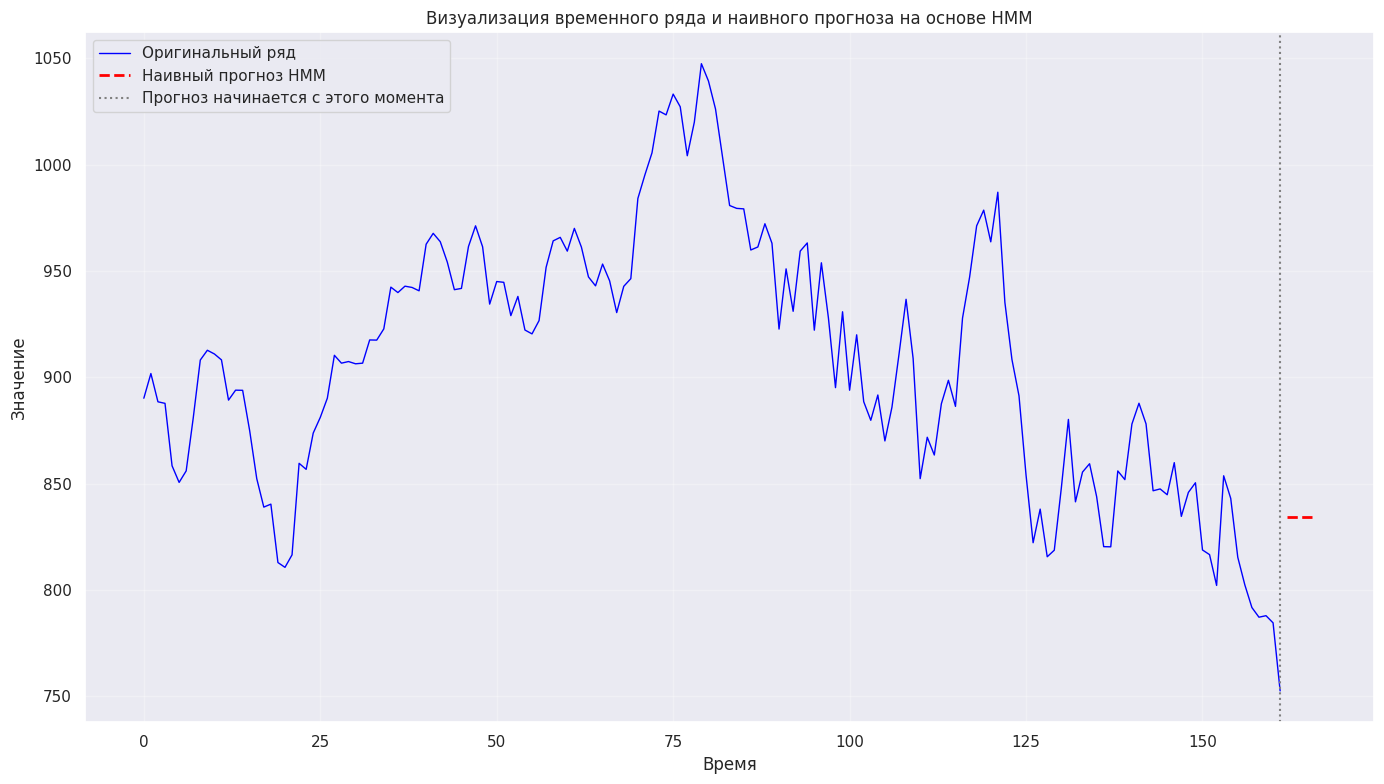

In [46]:
# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(14, 8))

# Оригинальный временной ряд
plt.plot(range(len(ts_data)), ts_data, label='Оригинальный ряд', color='blue', linewidth=1)

# Прогноз
forecast_start = len(ts_data)
forecast_end = forecast_start + len(naive_forecast)
plt.plot(range(forecast_start, forecast_end), naive_forecast, label='Наивный прогноз HMM', color='red', linestyle='--', linewidth=2)

# Разделение между историей и прогнозом
plt.axvline(x=len(ts_data)-1, color='gray', linestyle=':', label='Прогноз начинается с этого момента')

plt.title('Визуализация временного ряда и наивного прогноза на основе HMM')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

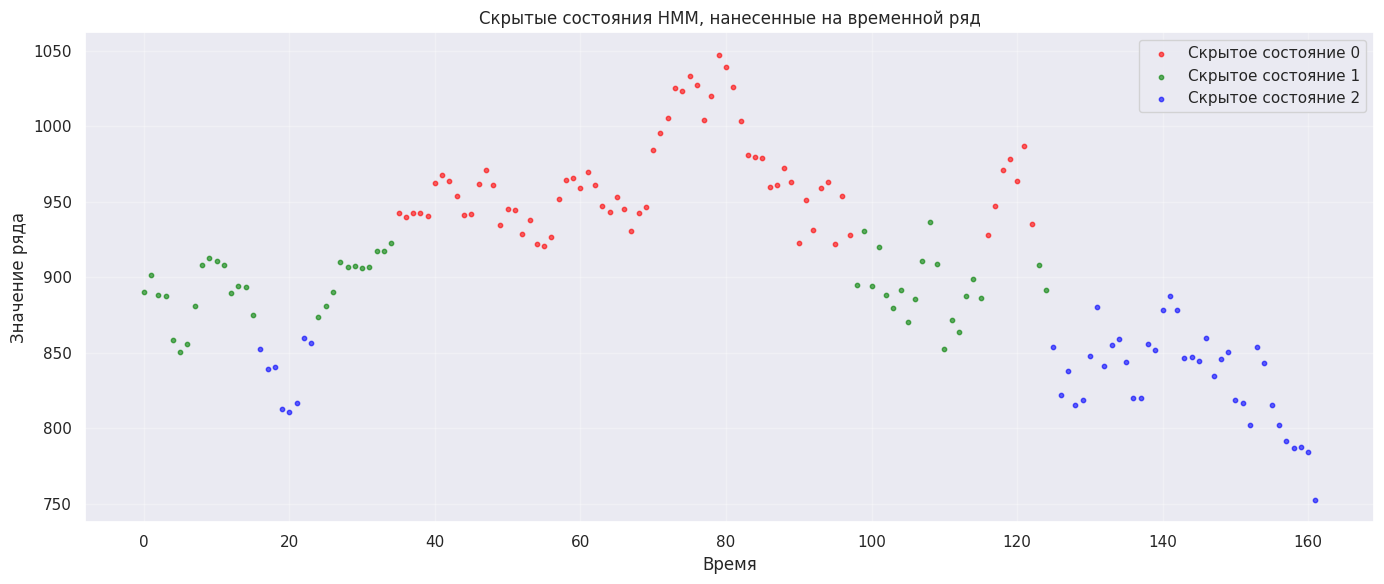

In [47]:
# Визуализация скрытых состояний
plt.figure(figsize=(14, 6))
colors = ['red', 'green', 'blue']
for i in range(3):
    state_mask = hidden_states == i
    plt.scatter(np.arange(len(hidden_states))[state_mask], ts_data[state_mask],
                c=colors[i], label=f'Скрытое состояние {i}', s=10, alpha=0.6)

plt.title('Скрытые состояния HMM, нанесенные на временной ряд')
plt.xlabel('Время')
plt.ylabel('Значение ряда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Результат [834.55928997 834.55928997 834.55928997 834.55928997 834.55928997] говорит о следующем:

Все 5 прогнозируемых значений одинаковы — это характерно для наивного подхода, который вы использовали: вы просто взяли среднее значение последнего предсказанного скрытого состояния и использовали его как прогноз на все будущие шаги.
Это не адаптивный прогноз — он не учитывает возможные тренды, сезонность или динамику ряда. Он просто "повторяет" среднее значение той компоненты HMM, в которой оказался последний элемент ряда.
Такой подход часто используется как базовая линия (baseline) для сравнения с более сложными моделями. Он не улавливает изменений в динамике ряда.
Почему так произошло:

HMM предсказал, что последнее состояние —, например, состояние 2.
Среднее значение этого состояния (после обратного преобразования из нормализованного вида) — 834.55928997.
Вы просто взяли это значение и повторили 5 раз.
Вывод:

Это корректный результат для реализованного вами наивного метода. Он показывает, что ваша HMM модель смогла выделить скрытые состояния, и вы использовали среднее значение компоненты для прогноза. Однако, для реального прогнозирования временного ряда, такой метод малоинформативен, так как не учитывает эволюцию скрытых состояний или динамику ряда. Это просто базовый прогноз, который можно использовать как отправную точку для сравнения с более сложными методами.